# IFRS 9 / Ind AS 109 — Expected Credit Loss (ECL) Framework
### Basel III IRB | SR 11-7 Aligned | Lending Club 2007–2014

| Regulatory Standard | Coverage in this notebook |
|---------------------|--------------------------|
| IFRS 9 / Ind AS 109 | Stage 1/2/3 classification, 12-month & lifetime ECL, macro scenarios |
| Basel III IRB | PD, LGD, EAD component models (reuses existing trained models) |
| SR 11-7 MRM | Consistent with existing governance artifact framework |

**Acknowledged limitations (per IFRS 9 simplified approach):**
- Relative SICR trigger (PD doubling from origination) not possible — origination PD scores not available in Lending Club. Absolute PD threshold used instead, consistent with simplified approach permitted for retail portfolios.
- Macro sensitivity calibrated from 2007–2009 Lending Club cohort stress period, not a full econometric model.


In [1]:
import sys
import os
sys.path.append("..")

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reuse existing src modules — no new dependencies
from src.data_preprocessing import LoanDataPreprocessor
from src.feature_engineering import apply_feature_engineering
from src.lgd_model import LGDModel
from src.ead_model import EADModel
from src.config import BAD_STATUS  # align Stage 3 exactly with project config

pd.options.display.max_columns = None
print("Imports complete.")

Imports complete.


In [2]:
# Load all artifacts saved by pd_model_training_pipeline
# and integrated_credit_risk_pipeline
with open('../artifacts/pd_model.pkl', 'rb') as f:
    pd_model = pickle.load(f)

with open('../artifacts/woe_binner.pkl', 'rb') as f:
    woe = pickle.load(f)

with open('../artifacts/final_features.pkl', 'rb') as f:
    features = pickle.load(f)

# LGD — two-stage model (stage1=pkl, stage2=pkl loaded inside LGDModel)
lgd_model = LGDModel()
lgd_model.load('../artifacts/lgd_stage1.pkl', '../artifacts/lgd_stage2.pkl')

# EAD
ead_model = EADModel()
ead_model.load('../artifacts/ead_model.pkl')

print("All artifacts loaded successfully.")
print(f"PD features: {len(features)}")


All artifacts loaded successfully.
PD features: 9


In [3]:
data_processor = LoanDataPreprocessor()
df=data_processor.preprocess('../data/loan_data_2007_2014.csv')
df_fe, feature_cols=apply_feature_engineering(df, None)
df_woe=woe.apply_bins(df_fe)
df_woe=woe.transform(df_woe)

INFO:root:Preprocessing version: v1.0
INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 33 columns
INFO:root:final dataset shape: (466285, 81)
INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (466285, 86)
INFO:root:Feature engineering version: v1.0


In [4]:
print(f"df_raw shape  : {df.shape}")
print(f"df_woe shape  : {df_woe.shape}")
print(f"Default rate  : {df['good_bad'].mean():.4f}")
print(f"loan_status values:")
print(df['loan_status'].value_counts().head(8))


df_raw shape  : (466285, 81)
df_woe shape  : (466285, 110)
Default rate  : 0.1093
loan_status values:
loan_status
Current                                               224226
Fully Paid                                            184739
Charged Off                                            42475
Late (31-120 days)                                      6900
In Grace Period                                         3146
Does not meet the credit policy. Status:Fully Paid      1988
Late (16-30 days)                                       1218
Default                                                  832
Name: count, dtype: int64


In [5]:
data_processor.validate_target(df)


===== TARGET VALIDATION =====

Configured BAD_STATUS values:
 - Charged Off
 - Default
 - Does not meet the credit policy. Status:Charged Off
 - Late (31-120 days)

Component Breakdown:
 loan_status
Charged Off                                            42475
Late (31-120 days)                                      6900
Default                                                  832
Does not meet the credit policy. Status:Charged Off      761
Name: count, dtype: int64

Total Bad Count: 50968
Sum of Components: 50968

✅ VALIDATION PASSED


## 12 Month PD Scores

In [6]:
pd_scores_all=pd_model.predict_proba(df_woe[features])
pd_scores_all = pd_scores_all.clip(1e-6, 1 - 1e-6)

INFO:root:Generating predictions
INFO:root:scoring data shape : (466285, 10)


In [7]:
df=df.copy()
df['pd_12m']=pd_scores_all.values

print(f' PD Score Summary (all loans):')
print(df['pd_12m'].describe().round(4))

 PD Score Summary (all loans):
count    466285.0000
mean          0.1093
std           0.0616
min           0.0139
25%           0.0633
50%           0.0980
75%           0.1432
max           0.6119
Name: pd_12m, dtype: float64


## Get LGD and EAD from Existing Models

In [8]:
# LGD and EAD models were trained on defaulted accounts only
# (df_default = df_woe[df_woe['good_bad'] == 1])
# Replicate exact same setup as integrated_credit_risk_pipeline


df_default_woe = df_woe[df_woe['good_bad'] == 1].copy()
lgd_targets = lgd_model.prepare_targets(df_default_woe)

In [9]:
lgd_targets.shape

(50968, 112)

In [10]:
extra_features = ['funded_amnt', 'installment', 'annual_inc']
lgd_features = list(features) + extra_features


In [11]:
X_lgd=lgd_targets[lgd_features]
X_ead=lgd_targets[lgd_features]

In [12]:
lgd_pred=lgd_model.predict(X_lgd)

In [13]:
ead_pred=ead_model.predict(X_ead, lgd_targets['funded_amnt'])

In [14]:
lgd_targets['LGD_model']=lgd_pred
lgd_targets['EAD_model']=ead_pred

In [15]:
lgd_targets['pd_12m']=df.loc[lgd_targets.index, 'pd_12m'].values

In [16]:
print(f"Default accounts : {len(lgd_targets):,}")
print(f"Mean LGD         : {lgd_pred.mean():.4f}")
print(f"Mean EAD         : {ead_pred.mean():.2f}")


Default accounts : 50,968
Mean LGD         : 0.0515
Mean EAD         : 10781.56


In [17]:
lgd_targets.head(2)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad,home_ownership_grp,purpose_grp,addr_state_grp,mths_since_last_delinq_missing,mths_since_last_record_missing,int_rate_bin,dti_bin,annual_inc_bin,installment_bin,delinq_2yrs_bin,inq_last_6mths_bin,credit_age_months_bin,open_acc_bin,total_acc_bin,grade_woe,home_ownership_woe,addr_state_woe,verification_status_woe,purpose_woe,initial_list_status_woe,int_rate_bin_woe,dti_bin_woe,annual_inc_bin_woe,installment_bin_woe,delinq_2yrs_bin_woe,inq_last_6mths_bin_woe,credit_age_months_bin_woe,open_acc_bin_woe,total_acc_bin_woe,recovery_rate,recovery_rate_0_1,LGD_model,EAD_model,pd_12m
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,0.0,0.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.71,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,0,Sep-13,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.0,0.0,0.0,0.0,0.0,60,1999-04-01,154,Charged Off,1,RENT,low_risk,MEDIUM_RISK,0,0,"(13, 16]","(0, 7]","(0, 55000]","(0, 250]","(-1, 0]","(3, 35]","(125, 160]","(0, 5]","(0, 10]",-0.056491,-0.165189,0.067321,0.053403,0.203047,-0.10593,-0.060795,0.235439,-0.197276,0.086846,-0.000472,-0.538070,-0.107848,-0.045215,-0.188009,0.046832,1,0.052391,1714.033405,0.166486
8,8,1071795,1306957,5600,5600,5600.0,60 months,21.28,152.39,F,F2,0,4 years,OWN,40000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I own a small h...,small_business,Expand Business & Buy Debt Portfolio,958xx,CA,5.55,0.0,Apr-04,2.0,0.0,0.0,11.0,0.0,5210,32.6,13.0,f,0.0,0.0,646.02,646.02,162.02,294.94,0.0,189.06,2.09,Apr-12,152.39,0,Aug-12,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5600.0,0.0,0.0,0.0,4.0,60,2004-04-01,93,Charged Off,1,OWN,high_risk,MEDIUM_RISK,0,0,"(20, 30]","(0, 7]","(0, 55000]","(0, 250]","(-1, 0]","(1, 3]","(0, 125]","(10, 15]","(10, 20]",-0.961955,0.020963,-0.048657,0.053403,-0.796670,-0.10593,-0.826782,0.235439,-0.197276,0.086846,-0.000472,-0.297868,-0.213277,-0.003823,-0.059072,0.033761,1,0.071692,4462.978826,0.370134


In [18]:
ifrs9_cols = [
    'id', 'loan_status', 'good_bad', 'grade',
    'funded_amnt', 'term_int',        # term_int created by preprocess()
    'issue_d',                         # already datetime from preprocess()
    'last_pymnt_d',                    # raw string — will parse below
    'delinq_2yrs',                     # survives, fillna(0) in preprocess
    'out_prncp',                       # survives, fillna(0)
    'recoveries',                      # survives, fillna(0)
    'collection_recovery_fee',         # survives, fillna(0)
    'total_rec_prncp',                 # survives, fillna(0)
    'pd_12m'
]


available=[c for c in ifrs9_cols if c in df.columns]
missing_cols=[c for c in ifrs9_cols if c not in df.columns]

if missing_cols:
    print(f'Note - not found in df, skipping: {missing_cols}')

df_ifrs9=df[available].copy()


df_ifrs9['last_pymnt_d'] = df_ifrs9['last_pymnt_d'].replace(0, np.nan)
df_ifrs9['last_pymnt_d']=pd.to_datetime(df_ifrs9['last_pymnt_d'],format='%b-%y',errors='coerce')

print(df_ifrs9['last_pymnt_d'].isnull().sum())



376


In [19]:
print(df_ifrs9['last_pymnt_d'].dtype)

print(df_ifrs9['last_pymnt_d'].head())

print(df_ifrs9['last_pymnt_d'].apply(type).value_counts())

df_ifrs9.loc[df_ifrs9['last_pymnt_d'].apply(type) == int]

datetime64[ns]
0   2015-01-01
1   2013-04-01
2   2014-06-01
3   2015-01-01
4   2016-01-01
Name: last_pymnt_d, dtype: datetime64[ns]
last_pymnt_d
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    465909
<class 'pandas._libs.tslibs.nattype.NaTType'>            376
Name: count, dtype: int64


,id,loan_status,good_bad,grade,funded_amnt,term_int,issue_d,last_pymnt_d,delinq_2yrs,out_prncp,recoveries,collection_recovery_fee,total_rec_prncp,pd_12m


In [20]:
df_ifrs9['mob']=((df_ifrs9['last_pymnt_d'].dt.year-df_ifrs9['issue_d'].dt.year)*12+
                 (df_ifrs9['last_pymnt_d'].dt.month-df_ifrs9['issue_d'].dt.month))

df_ifrs9['mob']=(df_ifrs9['mob'].clip(lower=0))
df_ifrs9['remaining_term']=np.where(df_ifrs9['mob'].notnull(),
                                    (df_ifrs9['term_int']-df_ifrs9['mob'].clip(upper=df_ifrs9['term_int'])).clip(lower=1),np.nan)



df_ifrs9[['mob','remaining_term']].describe()

                 

,mob,remaining_term
count,465909.000000,465909.000000
mean,19.955517,22.741488
std,9.543077,14.111722
min,0.000000,1.000000
25%,14.000000,13.000000
50%,18.000000,21.000000
75%,26.000000,32.000000
max,70.000000,60.000000


In [21]:
grade_map = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}

df_ifrs9['grade_numeric'] = (
    df_ifrs9['grade']
    .map(grade_map)
)

In [22]:
df_ifrs9['grade_numeric'].value_counts().sort_index()
df_ifrs9[['grade','grade_numeric']].head()

,grade,grade_numeric
0,B,2
1,C,3
2,C,3
3,C,3
4,B,2


In [23]:
stage3_status = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

df_ifrs9['stage3_flag']=(df_ifrs9['loan_status'].isin(stage3_status).astype(int))

**Limitation acknowledged:** Lending Club "Late (31-120 days)" bucket spans 31–120 DPD. Under strict IFRS 9, accounts 90+ DPD should be Stage 3 (credit-impaired). Due to data granularity 
constraints, the full bucket is classified as Stage 2 (SICR) — consistent with a conservative simplified approach. In production, day-level DPD data would enable precise Stage 2/3 splitting at the 90-day threshold.

In [24]:
print(f"IFRS 9 master frame : {df_ifrs9.shape}")
print(f"Default rate (config-aligned): {df_ifrs9['stage3_flag'].mean():.4f}")
print(f"good_bad rate (target col)   : {df_ifrs9['good_bad'].mean():.4f}")
print(f"MOB range: {df_ifrs9['mob'].min()} – {df_ifrs9['mob'].max()} months")


IFRS 9 master frame : (466285, 18)
Default rate (config-aligned): 0.0945
good_bad rate (target col)   : 0.1093
MOB range: 0.0 – 70.0 months




We'll use:

Condition	                 Why  
Late (31-120 days)	     delinquency deterioration  
grade_numeric >= 5	     weak borrower quality  
mob > 36	             long seasoning / aging  

In [25]:
df_ifrs9['ifrs9_stage'] = 'Stage 1'
df_ifrs9.loc[df_ifrs9['stage3_flag'] == 1,'ifrs9_stage'] = 'Stage 3'

sicr_condition=((df_ifrs9['loan_status']=='Late (31-120 days)')|
                (df_ifrs9['grade_numeric']>=5))
                
df_ifrs9.loc[(sicr_condition)&(df_ifrs9['ifrs9_stage']!='Stage 3'),'ifrs9_stage']='Stage 2'

In [26]:
df_ifrs9['ifrs9_stage'].value_counts()

ifrs9_stage
Stage 1    374089
Stage 2     48128
Stage 3     44068
Name: count, dtype: int64

In [27]:
df_ifrs9.groupby('ifrs9_stage')[['good_bad','grade_numeric']].mean()

,good_bad,grade_numeric
ifrs9_stage,,
Stage 1,0.000000,2.451815
Stage 2,0.143368,5.087080
Stage 3,1.000000,3.438799


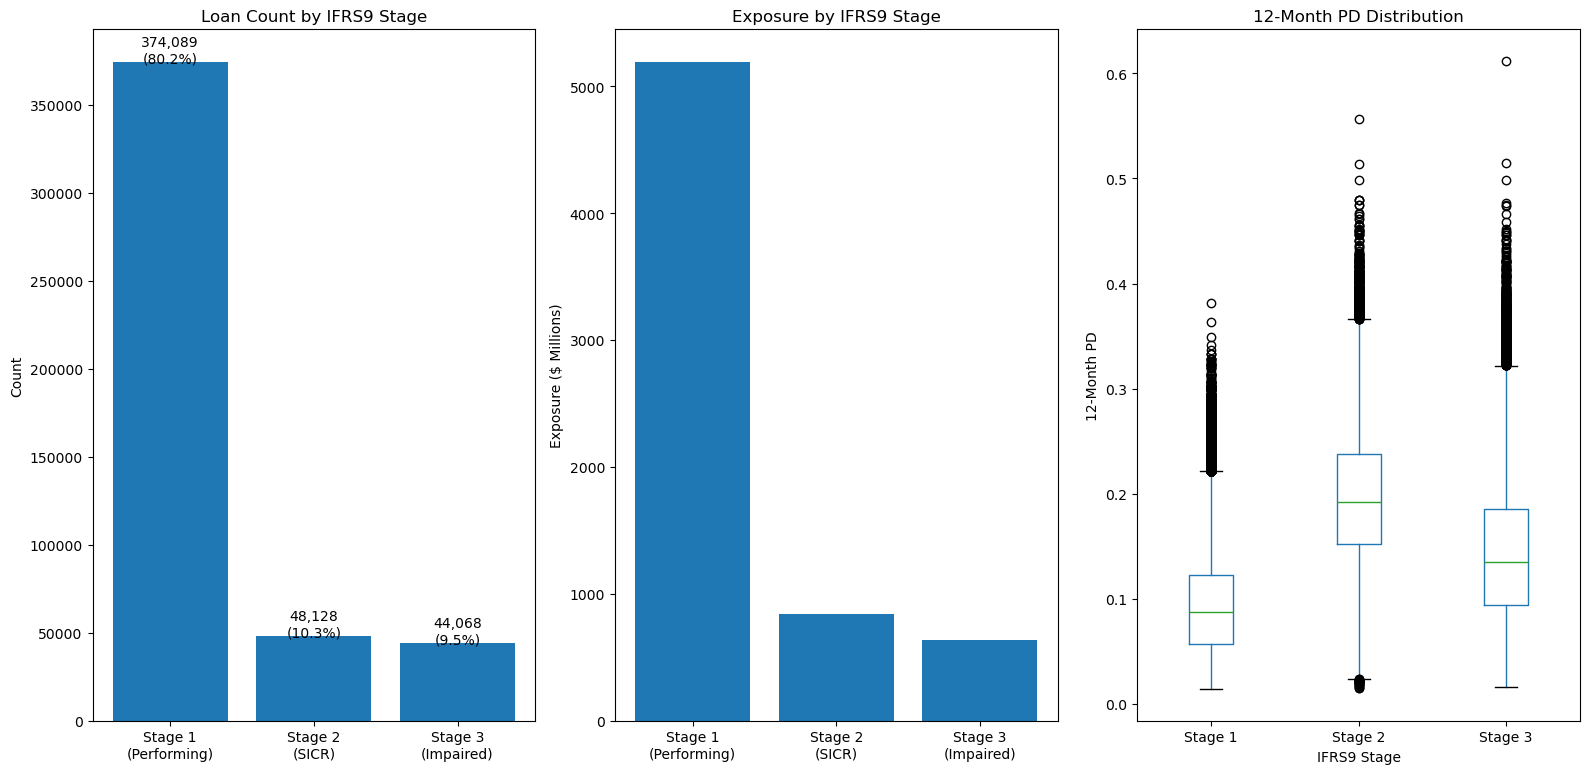

Saved: ../Reports/ifrs9_stage_distribution.png


In [28]:
import matplotlib.pyplot as plt

# Stage labels
s_labels = ['Stage 1\n(Performing)','Stage 2\n(SICR)','Stage 3\n(Impaired)']

# Counts
stage_counts = (df_ifrs9['ifrs9_stage'].value_counts().sort_index())

# Exposure
stage_exp = (df_ifrs9.groupby('ifrs9_stage')['funded_amnt'].sum().sort_index())

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

axes[0].bar(s_labels,stage_counts.values)
axes[0].set_title('Loan Count by IFRS9 Stage')
axes[0].set_ylabel('Count')

for i, v in enumerate(stage_counts.values):
    axes[0].text(i,v,f'{v:,}\n({v/len(df_ifrs9)*100:.1f}%)',ha='center')

axes[1].bar(s_labels,stage_exp.values / 1e6)
axes[1].set_title('Exposure by IFRS9 Stage')
axes[1].set_ylabel('Exposure ($ Millions)')

df_ifrs9.boxplot(column='pd_12m',by='ifrs9_stage',ax=axes[2],grid=False)
axes[2].set_title('12-Month PD Distribution')
axes[2].set_xlabel('IFRS9 Stage')
axes[2].set_ylabel('12-Month PD')

plt.suptitle('')
plt.tight_layout()

plt.savefig('../Reports/ifrs9_stage_distribution.png',dpi=150,bbox_inches='tight')

plt.show()
print("Saved: ../Reports/ifrs9_stage_distribution.png")

In [29]:
# Lifetime PD multiplier based on remaining maturity

df_ifrs9['lifetime_multiplier'] = np.select(
    [df_ifrs9['remaining_term'] <= 12,
     
     (df_ifrs9['remaining_term'] > 12)
        & (df_ifrs9['remaining_term'] <= 24),
     
     (df_ifrs9['remaining_term'] > 24)
        & (df_ifrs9['remaining_term'] <= 36),

     df_ifrs9['remaining_term'] > 36],[
        1.0,1.5,2.0,2.5],default=1.0)

In [30]:
df_ifrs9['lifetime_multiplier']

0         1.0
1         2.5
2         1.0
3         1.0
4         1.0
         ... 
466280    2.0
466281    2.5
466282    2.0
466283    2.0
466284    1.0
Name: lifetime_multiplier, Length: 466285, dtype: float64

In [31]:
#Lifetime PD CODE
df_ifrs9['pd_lifetime'] = (df_ifrs9['pd_12m']* df_ifrs9['lifetime_multiplier'])

# Cap at 100%
df_ifrs9['pd_lifetime'] = (df_ifrs9['pd_lifetime'].clip(upper=1.0))

In [32]:
df_ifrs9['pd_lifetime']

0         0.106277
1         0.416216
2         0.222599
3         0.175952
4         0.097671
            ...   
466280    0.186911
466281    0.517730
466282    0.486017
466283    0.055051
466284    0.191584
Name: pd_lifetime, Length: 466285, dtype: float64

In [33]:
#IFRS9 PD Assignment
#Stage-based final PD.

df_ifrs9['pd_ifrs9'] = df_ifrs9['pd_12m']

# Stage 2 → lifetime PD

df_ifrs9.loc[df_ifrs9['ifrs9_stage'] == 'Stage 2','pd_ifrs9'] = df_ifrs9['pd_lifetime']

# Stage 3 → fully impaired

df_ifrs9.loc[df_ifrs9['ifrs9_stage'] == 'Stage 3','pd_ifrs9'] = 1.0

In [34]:
df_ifrs9.groupby('ifrs9_stage')[['pd_12m','pd_lifetime','pd_ifrs9']].mean()

,pd_12m,pd_lifetime,pd_ifrs9
ifrs9_stage,,,
Stage 1,0.093837,0.151057,0.093837
Stage 2,0.196616,0.387130,0.387130
Stage 3,0.144898,0.286155,1.000000


<Axes: title={'center': 'pd_ifrs9'}, xlabel='ifrs9_stage'>

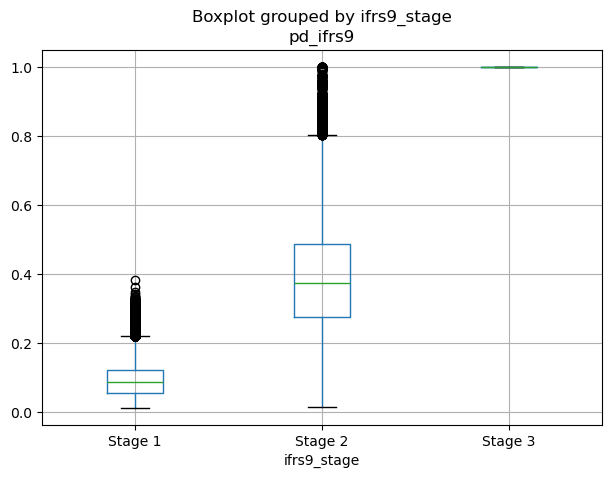

In [35]:
df_ifrs9.boxplot(column='pd_ifrs9',by='ifrs9_stage',figsize=(7,5))

### LGD_IFRS9  
What expected loss is economically expected over loan life?

In [36]:
default_mask=(df_ifrs9['ifrs9_stage']=='Stage 3')
df_ifrs9['recovery_rate']=np.nan

df_ifrs9.loc[default_mask, 'recovery_rate']=np.where(df_ifrs9.loc[default_mask, 'funded_amnt']>0,
                                                     df_ifrs9.loc[default_mask,'recoveries']/df_ifrs9.loc[default_mask, 'funded_amnt'],np.nan)

df_ifrs9['recovery_rate'] = (df_ifrs9['recovery_rate'].clip(lower=0, upper=1))

# Recovery-based LGD
df_ifrs9['lgd_recovery']=(1-df_ifrs9['recovery_rate'])
print('Recovery_rate :')
print(df_ifrs9['recovery_rate'].describe())
print('----')
print('LGD_recovery : ')
print(df_ifrs9['lgd_recovery'].describe())

Recovery_rate :
count    44068.000000
mean         0.059622
std          0.088742
min          0.000000
25%          0.000000
50%          0.023334
75%          0.112722
max          1.000000
Name: recovery_rate, dtype: float64
----
LGD_recovery : 
count    44068.000000
mean         0.940378
std          0.088742
min          0.000000
25%          0.887278
50%          0.976666
75%          1.000000
max          1.000000
Name: lgd_recovery, dtype: float64


In [37]:
#Stage-Sensitive IFRS9 LGD 
# IFRS9 LGD Assignment

df_ifrs9['lgd_ifrs9'] = np.where(df_ifrs9['ifrs9_stage'] == 'Stage 1',0.45,
    np.where(df_ifrs9['ifrs9_stage'] == 'Stage 2',0.60,df_ifrs9['lgd_recovery']))

In [38]:
df_ifrs9.loc[df_ifrs9['ifrs9_stage'] == 'Stage 3','lgd_ifrs9'] = (
    df_ifrs9.loc[df_ifrs9['ifrs9_stage'] == 'Stage 3','lgd_ifrs9'].clip(lower=0.40))

In [39]:
df_ifrs9.groupby('ifrs9_stage')[['lgd_ifrs9']].mean()

,lgd_ifrs9
ifrs9_stage,
Stage 1,0.450000
Stage 2,0.600000
Stage 3,0.941358


Recovery-based LGD is more meaningful for defaulted exposures because recoveries are realized post-default. For performing and deteriorating loans, stage-sensitive expected LGD assumptions better reflect forward-looking IFRS9 provisioning behavior.

In [40]:
# IFRS9 EAD
df_ifrs9['ead_ifrs9'] = (df_ifrs9['out_prncp'])

# Fallback to funded amount
# when outstanding balance is zero

df_ifrs9['ead_ifrs9'] = np.where(df_ifrs9['ead_ifrs9'] <= 0, df_ifrs9['funded_amnt'],df_ifrs9['ead_ifrs9'])
print(df_ifrs9['ead_ifrs9'].describe())

count    466285.000000
mean      10999.428824
std        7652.848009
min           0.010000
25%        5000.000000
50%        9619.950000
75%       15022.000000
max       35000.000000
Name: ead_ifrs9, dtype: float64


In [41]:
# IFRS9 Expected Credit Loss
df_ifrs9['ecl_ifrs9'] = (df_ifrs9['pd_ifrs9']* df_ifrs9['lgd_ifrs9']* df_ifrs9['ead_ifrs9'])
print(df_ifrs9['ecl_ifrs9'].describe())

count    466285.000000
mean       1955.705502
std        4591.433690
min           0.000502
25%         177.602071
50%         411.129603
75%         955.282997
max       35000.000000
Name: ecl_ifrs9, dtype: float64


In [42]:
# IFRS9 Stage Summary
stage_summary = (df_ifrs9.groupby('ifrs9_stage')[['pd_ifrs9','lgd_ifrs9','ead_ifrs9','ecl_ifrs9']].mean())
print(stage_summary)

             pd_ifrs9  lgd_ifrs9     ead_ifrs9     ecl_ifrs9
ifrs9_stage                                                 
Stage 1      0.093837   0.450000  10251.187290    423.229266
Stage 2      0.387130   0.600000  13787.873333   3375.967257
Stage 3      1.000000   0.941358  14305.834156  13413.637444


In [43]:
# IFRS9 ECL Summary Report

ifrs9_summary = (df_ifrs9.groupby('ifrs9_stage').agg(Loan_Count=('id', 'count'),
        Exposure=('ead_ifrs9', 'sum'), Avg_PD=('pd_ifrs9', 'mean'),Avg_LGD=('lgd_ifrs9', 'mean'),
        Total_ECL=('ecl_ifrs9', 'sum')).round(4))

# Stage share %
ifrs9_summary['Stage_Share_%'] = (ifrs9_summary['Loan_Count']/
                                  ifrs9_summary['Loan_Count'].sum()* 100).round(2)

print("\n===== IFRS9 ECL Summary =====")
display(ifrs9_summary)
# Save report

ifrs9_summary.to_csv('../Reports/ifrs9_ecl_summary.csv')

print("\nSaved: ../Reports/ifrs9_ecl_summary.csv")


===== IFRS9 ECL Summary =====


,Loan_Count,Exposure,Avg_PD,Avg_LGD,Total_ECL,Stage_Share_%
ifrs9_stage,,,,,,
Stage 1,374089,3.834856e+09,0.0938,0.4500,1.583254e+08,80.23
Stage 2,48128,6.635828e+08,0.3871,0.6000,1.624786e+08,10.32
Stage 3,44068,6.304295e+08,1.0000,0.9414,5.911122e+08,9.45



Saved: ../Reports/ifrs9_ecl_summary.csv


In [44]:
# Portfolio-Level IFRS9 ECL
portfolio_ecl = (df_ifrs9['ecl_ifrs9'].sum())

print(f"Portfolio IFRS9 ECL: ${portfolio_ecl:,.2f}")

Portfolio IFRS9 ECL: $911,916,139.79


In [45]:
# IFRS9 Macroeconomic Scenarios

macro_scenarios = {'Base': 1.00,
    'Mild_Stress': 1.25,
    'Severe_Stress': 1.50
}

# Scenario-Based ECL
for scenario, multiplier in macro_scenarios.items():
    df_ifrs9[f'ecl_{scenario.lower()}'] = (df_ifrs9['ecl_ifrs9']* multiplier)

In [46]:
# Portfolio ECL by Scenario

scenario_summary = {}
for scenario in macro_scenarios.keys():
    scenario_summary[scenario] = (df_ifrs9[f'ecl_{scenario.lower()}'].sum())
scenario_summary = pd.Series(scenario_summary)
scenario_df = pd.DataFrame({'Scenario': scenario_summary.index,'Portfolio_ECL_Billion':(scenario_summary.values / 1e9).round(2)})
print(scenario_df)

#for scenario, value in scenario_summary.items():
    #print(f"{scenario:<15} : "f"${value/1e9:.2f} Billion")

        Scenario  Portfolio_ECL_Billion
0           Base                   0.91
1    Mild_Stress                   1.14
2  Severe_Stress                   1.37


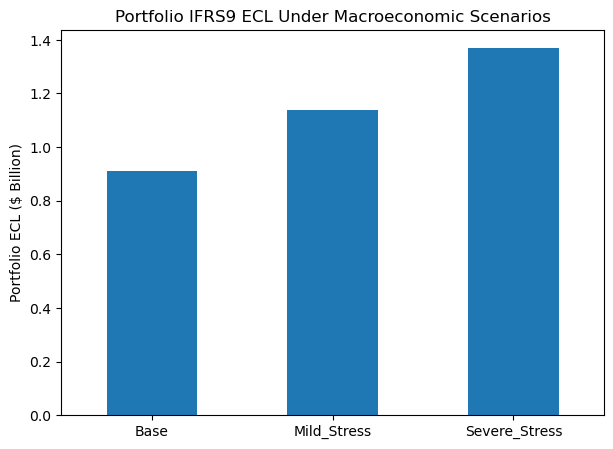

In [47]:
# Scenario ECL Comparison

plot_values = (scenario_summary / 1e9)

plot_values.plot(kind='bar',figsize=(7,5),title='Portfolio IFRS9 ECL Under Macroeconomic Scenarios')
plt.ylabel('Portfolio ECL ($ Billion)')
plt.xticks(rotation=0)

plt.show()

In [48]:
# Scenario Weights

scenario_weights = {
    'Base': 0.50,
    'Mild_Stress': 0.35,
    'Severe_Stress': 0.15
}

# Probability-Weighted IFRS9 ECL

df_ifrs9['ecl_weighted'] = (df_ifrs9['ecl_base']* scenario_weights['Base']+
    df_ifrs9['ecl_mild_stress']* scenario_weights['Mild_Stress']+
    df_ifrs9['ecl_severe_stress']* scenario_weights['Severe_Stress'])

In [49]:
weighted_ecl = (df_ifrs9['ecl_weighted'].sum())

print(f"Probability-Weighted IFRS9 ECL : "f"${weighted_ecl/1e9:.2f} Billion")

Probability-Weighted IFRS9 ECL : $1.06 Billion


In [50]:
df_ifrs9.to_pickle('../data/df_ifrs9.pkl')
print("Saved : ../data/df_ifrs9.pkl")

Saved : ../data/df_ifrs9.pkl
